In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Acer/Downloads/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, ":", (df[col] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [12]:
# Columns where zero is medically unrealistic
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0 with NaN
df[zero_columns] = df[zero_columns].replace(0, np.nan)

# Check missing values after replacement
df.isnull().sum()

for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [27]:
df.to_csv("C:/Users/Acer/Downloads/diabetes_cleaned.csv", index = False)
df2 = pd.read_csv("C:/Users/Acer/Downloads/diabetes_cleaned.csv")

In [35]:
df2.head()
df2.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [37]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, "zeros:", (df2[col] == 0).sum())

Glucose zeros: 0
BloodPressure zeros: 0
SkinThickness zeros: 0
Insulin zeros: 0
BMI zeros: 0


In [39]:
df2.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [41]:
df2.shape

(768, 9)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and target
X = df2.drop("Outcome", axis=1)
y = df2["Outcome"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)



# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7792207792207793

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


Confusion Matrix:
[[88 12]
 [22 32]]


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

balanced_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.7402597402597403

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Confusion Matrix:
[[84 16]
 [24 30]]


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Class_1": precision_score(y_test, y_pred),
        "Recall_Class_1": recall_score(y_test, y_pred),
        "F1_Class_1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1_Class_1", ascending=False)

,Model,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
2,Random Forest,0.779221,0.727273,0.592593,0.653061
3,Gradient Boosting,0.759740,0.688889,0.574074,0.626263
0,Logistic Regression,0.701299,0.586957,0.500000,0.540000
4,SVM,0.720779,0.648649,0.444444,0.527473
1,Decision Tree,0.681818,0.553191,0.481481,0.514851


In [46]:
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

# Predict class
y_pred = final_model.predict(X_test)

# Predict probability of diabetes risk
y_proba = final_model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_proba[:10])

First 10 predicted probabilities:
[0.67 0.24 0.07 0.28 0.09 0.28 0.51 0.78 0.1  0.82]


In [47]:
def risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Risk_Probability": y_proba,
    "Risk_Category": [risk_category(p) for p in y_proba]
})

risk_results.head(10)

,Actual,Predicted,Risk_Probability,Risk_Category
0,0,1,0.67,High Risk
1,0,0,0.24,Low Risk
2,0,0,0.07,Low Risk
3,1,0,0.28,Low Risk
4,0,0,0.09,Low Risk
5,0,0,0.28,Low Risk
6,1,1,0.51,Medium Risk
7,1,1,0.78,High Risk
8,0,0,0.10,Low Risk
9,0,1,0.82,High Risk


In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7727272727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154


Confusion Matrix:
[[85 15]
 [20 34]]


In [60]:
new_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Class_1": precision_score(y_test, y_pred),
        "Recall_Class_1": recall_score(y_test, y_pred),
        "F1_Class_1": f1_score(y_test, y_pred)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision_Class_1": precision_score(y_test, y_pred_xgb),
        "Recall_Class_1": recall_score(y_test, y_pred_xgb),
        "F1_Class_1": f1_score(y_test, y_pred_xgb)
    },
    {
        "Model": "XGBoost Balanced",
        "Accuracy": accuracy_score(y_test, y_pred_xgb_balanced),
        "Precision_Class_1": precision_score(y_test, y_pred_xgb_balanced),
        "Recall_Class_1": recall_score(y_test, y_pred_xgb_balanced),
        "F1_Class_1": f1_score(y_test, y_pred_xgb_balanced)
    },
    {
        "Model": "LightGBM Balanced",
        "Accuracy": accuracy_score(y_test, y_pred_lgbm),
        "Precision_Class_1": precision_score(y_test, y_pred_lgbm),
        "Recall_Class_1": recall_score(y_test, y_pred_lgbm),
        "F1_Class_1": f1_score(y_test, y_pred_lgbm)
    }
])

new_comparison.sort_values(by="F1_Class_1", ascending=False)

,Model,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
3,LightGBM Balanced,0.766234,0.650000,0.722222,0.684211
2,XGBoost Balanced,0.753247,0.629032,0.722222,0.672414
1,XGBoost,0.772727,0.693878,0.629630,0.660194
0,Random Forest,0.779221,0.727273,0.592593,0.653061


In [55]:
# Ratio of negative to positive cases in training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_balanced = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_balanced.fit(X_train, y_train)

y_pred_xgb_balanced = xgb_balanced.predict(X_test)
y_proba_xgb_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_balanced))

Accuracy: 0.7532467532467533

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       100
           1       0.63      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154


Confusion Matrix:
[[77 23]
 [15 39]]


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_threshold = (y_proba_xgb_balanced >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision_Class_1": precision_score(y_test, y_pred_threshold),
        "Recall_Class_1": recall_score(y_test, y_pred_threshold),
        "F1_Class_1": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(by="F1_Class_1", ascending=False)

,Threshold,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
0,0.25,0.740260,0.583333,0.907407,0.710145
2,0.35,0.733766,0.582278,0.851852,0.691729
3,0.40,0.740260,0.594595,0.814815,0.687500
1,0.30,0.720779,0.567901,0.851852,0.681481
5,0.50,0.753247,0.629032,0.722222,0.672414
4,0.45,0.733766,0.594203,0.759259,0.666667
6,0.55,0.753247,0.633333,0.703704,0.666667
7,0.60,0.766234,0.673077,0.648148,0.660377


In [58]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [59]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

threshold_results_lgbm = []

for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_lgbm_threshold = (y_proba_lgbm >= threshold).astype(int)
    
    threshold_results_lgbm.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_lgbm_threshold),
        "Precision_Class_1": precision_score(y_test, y_pred_lgbm_threshold),
        "Recall_Class_1": recall_score(y_test, y_pred_lgbm_threshold),
        "F1_Class_1": f1_score(y_test, y_pred_lgbm_threshold)
    })

threshold_lgbm_df = pd.DataFrame(threshold_results_lgbm)
threshold_lgbm_df.sort_values(by="F1_Class_1", ascending=False)

,Threshold,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
4,0.40,0.740260,0.594595,0.814815,0.687500
6,0.50,0.766234,0.650000,0.722222,0.684211
3,0.35,0.727273,0.576923,0.833333,0.681818
7,0.55,0.772727,0.672727,0.685185,0.678899
2,0.30,0.714286,0.560976,0.851852,0.676471
0,0.20,0.688312,0.533333,0.888889,0.666667
1,0.25,0.694805,0.541176,0.851852,0.661871
5,0.45,0.733766,0.597015,0.740741,0.661157
8,0.60,0.766234,0.680000,0.629630,0.653846


In [62]:
best_xgb_threshold = threshold_df.sort_values(by="F1_Class_1", ascending=False).iloc[0]
best_lgbm_threshold = threshold_lgbm_df.sort_values(by="F1_Class_1", ascending=False).iloc[0]

final_threshold_comparison = pd.DataFrame([
    {
        "Model": "XGBoost Balanced Tuned",
        "Threshold": best_xgb_threshold["Threshold"],
        "Accuracy": best_xgb_threshold["Accuracy"],
        "Precision_Class_1": best_xgb_threshold["Precision_Class_1"],
        "Recall_Class_1": best_xgb_threshold["Recall_Class_1"],
        "F1_Class_1": best_xgb_threshold["F1_Class_1"]
    },
    {
        "Model": "LightGBM Balanced Tuned",
        "Threshold": best_lgbm_threshold["Threshold"],
        "Accuracy": best_lgbm_threshold["Accuracy"],
        "Precision_Class_1": best_lgbm_threshold["Precision_Class_1"],
        "Recall_Class_1": best_lgbm_threshold["Recall_Class_1"],
        "F1_Class_1": best_lgbm_threshold["F1_Class_1"]
    }
])

final_threshold_comparison.sort_values(by="F1_Class_1", ascending=False)

,Model,Threshold,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
0,XGBoost Balanced Tuned,0.25,0.74026,0.583333,0.907407,0.710145
1,LightGBM Balanced Tuned,0.40,0.74026,0.594595,0.814815,0.687500


In [63]:
import joblib

final_model = xgb_balanced
final_threshold = 0.25

joblib.dump(final_model, "C:/Users/Acer/Downloads/diabetes_xgb_digital_twin_model.pkl")
joblib.dump(final_threshold, "C:/Users/Acer/Downloads/diabetes_risk_threshold.pkl")

['C:/Users/Acer/Downloads/diabetes_risk_threshold.pkl']

In [64]:
loaded_model = joblib.load("C:/Users/Acer/Downloads/diabetes_xgb_digital_twin_model.pkl")
loaded_threshold = joblib.load("C:/Users/Acer/Downloads/diabetes_risk_threshold.pkl")

sample_patient = X_test.iloc[[0]]

risk_probability = loaded_model.predict_proba(sample_patient)[:, 1][0]
risk_prediction = int(risk_probability >= loaded_threshold)

print("Risk probability:", risk_probability)
print("Risk prediction:", risk_prediction)

Risk probability: 0.87994105
Risk prediction: 1


In [65]:
virtual_patient = {
    "Pregnancies": 2,
    "Glucose": 150,
    "BloodPressure": 85,
    "SkinThickness": 30,
    "Insulin": 130,
    "BMI": 32.5,
    "DiabetesPedigreeFunction": 0.55,
    "Age": 45
}

virtual_patient_df = pd.DataFrame([virtual_patient])

virtual_patient_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,150,85,30,130,32.5,0.55,45


In [66]:
risk_probability = loaded_model.predict_proba(virtual_patient_df)[:, 1][0]
risk_prediction = int(risk_probability >= loaded_threshold)

print("Risk probability:", round(risk_probability * 100, 2), "%")
print("Risk prediction:", risk_prediction)

Risk probability: 84.85 %
Risk prediction: 1


In [67]:
def risk_category(probability):
    if probability < 0.25:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

category = risk_category(risk_probability)

print("Risk category:", category)

Risk category: High Risk


In [68]:
# Select one patient from the test set
patient_index = 0

real_patient = X_test.iloc[[patient_index]].copy()
actual_outcome = y_test.iloc[patient_index]

real_patient

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40


In [69]:
#predict risk 

real_patient_probability = loaded_model.predict_proba(real_patient)[:, 1][0]
real_patient_prediction = int(real_patient_probability >= loaded_threshold)

print("Actual outcome:", actual_outcome)
print("Predicted risk probability:", round(real_patient_probability * 100, 2), "%")
print("Predicted risk class:", real_patient_prediction)
print("Risk category:", risk_category(real_patient_probability))

Actual outcome: 0
Predicted risk probability: 87.99 %
Predicted risk class: 1
Risk category: High Risk


In [70]:
# Create a simulated improved version of the same patient
simulated_patient = real_patient.copy()

# Example lifestyle/clinical improvement scenario
simulated_patient["Glucose"] = simulated_patient["Glucose"] * 0.85   # 15% lower glucose
simulated_patient["BMI"] = simulated_patient["BMI"] * 0.90           # 10% lower BMI
simulated_patient["BloodPressure"] = simulated_patient["BloodPressure"] * 0.95  # 5% lower BP

simulated_patient

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,135.15,60.8,29.0,125.0,24.66,0.294,40


In [72]:
#comapring before and after

comparison_df = pd.DataFrame({
    "Metric": ["Risk Probability", "Risk Category"],
    "Before Simulation": [
        f"{before_probability * 100:.2f}%",
        risk_category(before_probability)
    ],
    "After Simulation": [
        f"{after_probability * 100:.2f}%",
        risk_category(after_probability)
    ]
})

comparison_df

#Real patient profile → virtual twin → simulate changes → predict new risk 
#real idea 

,Metric,Before Simulation,After Simulation
0,Risk Probability,87.99%,24.07%
1,Risk Category,High Risk,Low Risk


In [73]:
import joblib

joblib.dump(xgb_balanced, "C:/Users/Acer/Documents/healthcare-digital-twin/models/diabetes_xgb_digital_twin_model.pkl")
joblib.dump(0.25, "C:/Users/Acer/Documents/healthcare-digital-twin/models/diabetes_risk_threshold.pkl")

['C:/Users/Acer/Documents/healthcare-digital-twin/models/diabetes_risk_threshold.pkl']

In [74]:
import os

print(os.path.exists("C:/Users/Acer/Documents/healthcare-digital-twin/models/diabetes_xgb_digital_twin_model.pkl"))
print(os.path.exists("C:/Users/Acer/Documents/healthcare-digital-twin/models/diabetes_risk_threshold.pkl"))

True
True


In [75]:
feature_importance_df = pd.DataFrame({
    "Feature": xgb_balanced.feature_names_in_,
    "Importance": xgb_balanced.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
1,Glucose,0.271222
5,BMI,0.151453
7,Age,0.136144
0,Pregnancies,0.094835
6,DiabetesPedigreeFunction,0.094488
4,Insulin,0.094340
3,SkinThickness,0.080123
2,BloodPressure,0.077394


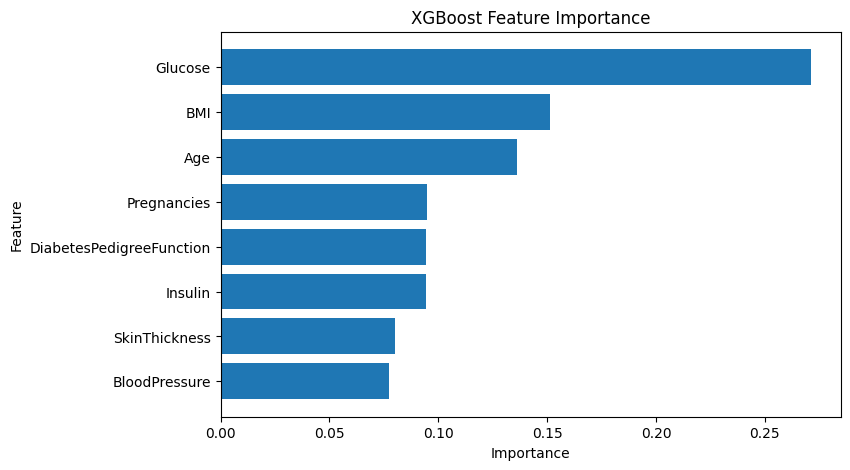

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

### Feature Importance Interpretation

The XGBoost model identified glucose, BMI, and age as the most important predictors for diabetes-risk classification. This aligns with domain expectations, as glucose level and BMI are clinically relevant indicators associated with diabetes risk. Feature importance was included to improve model interpretability.

In [78]:
pip install shap


Note: you may need to restart the kernel to use updated packages.Collecting shap
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 3.8 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.6 MB 6.3 MB/s eta 0:00:03
   ------ --------------------------------- 2.4/15.6 MB 5.6 MB/s eta 0:00:03
   -------- ------------------------------- 3.4/15.6 MB 5.4 MB/s eta 0:00:03
   ----------- ---------------------------- 4.5/15.6 MB 5.5 MB/s eta 0:00:03
   -------------- ------------------------- 5.8/15.6 MB 5.5 MB/s eta 0:00:02
   ----------------- ---------------------- 6.8/15.6 MB 5.4 MB/s eta 0:00:02
   -------------------- ------------------- 8.1/15.6 MB 5.5 MB/s eta 0:00:02
   ----------------------- ---------------- 9

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bayesflow 2.0.4 requires numpy<2.0,>=1.24, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.0 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 14.0.0 which is incompatible.


In [79]:
import shap

# Create SHAP explainer for the final XGBoost model
explainer = shap.TreeExplainer(xgb_balanced)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


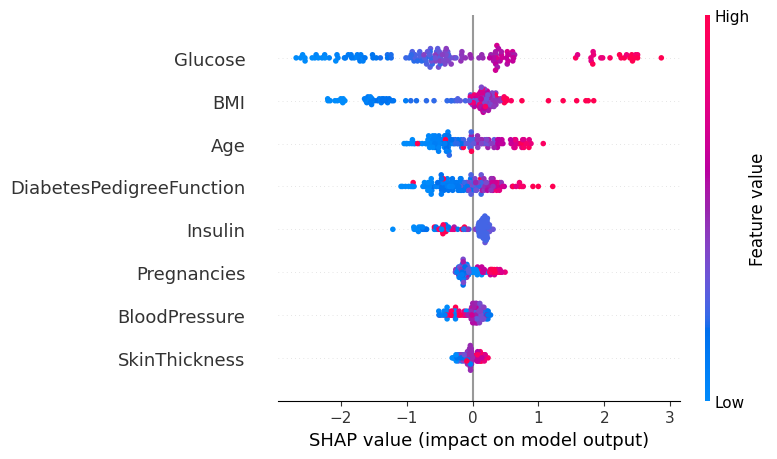

In [80]:
shap.summary_plot(shap_values, X_test)
#The SHAP summary plot shows that high glucose values strongly increase predicted diabetes risk, while lower glucose values generally reduce the prediction. BMI and age also show strong influence on the model output.

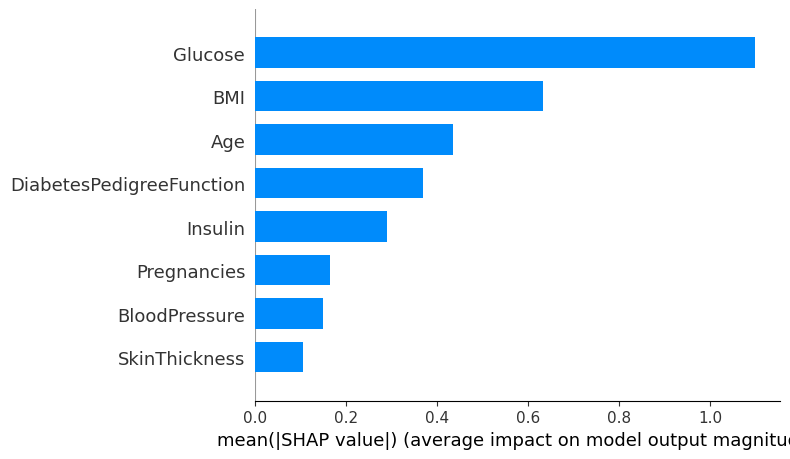

In [81]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [82]:
patient_index = 0

single_patient = X_test.iloc[[patient_index]]

single_patient_probability = xgb_balanced.predict_proba(single_patient)[:, 1][0]
single_patient_prediction = int(single_patient_probability >= 0.25)

print("Predicted risk probability:", round(single_patient_probability * 100, 2), "%")
print("Predicted risk class:", single_patient_prediction)
single_patient

Predicted risk probability: 87.99 %
Predicted risk class: 1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40


In [83]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[patient_index],
    X_test.iloc[patient_index]
)

#For the selected virtual patient, SHAP shows that high glucose was the main factor increasing the predicted diabetes risk. Some features, such as BMI and Diabetes Pedigree Function, reduced the risk prediction, but the positive contribution from glucose was strong enough to push the patient into a high-risk category

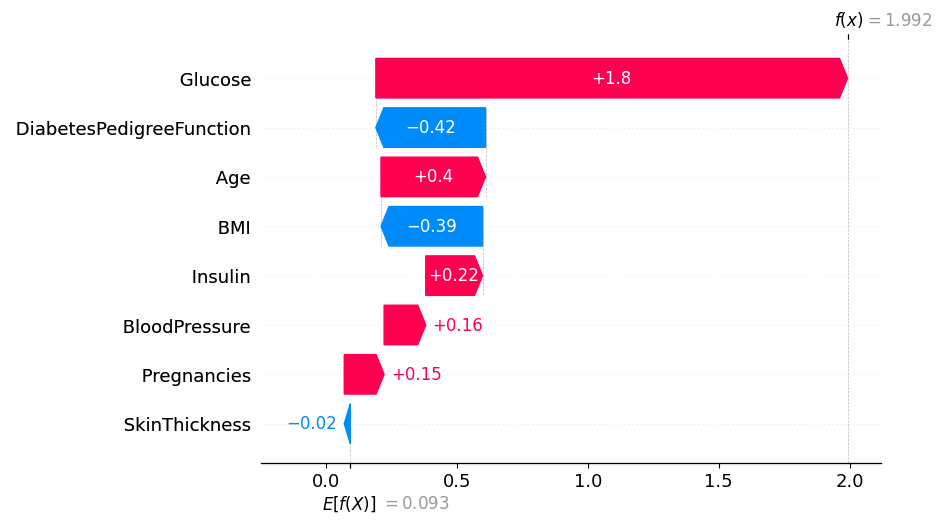

In [84]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[patient_index],
    X_test.iloc[patient_index]
)

### SHAP Interpretation

The SHAP analysis shows how each clinical indicator contributes to the model's diabetes-risk predictions. Features such as glucose, BMI, and age show strong influence on the predicted risk, which is consistent with the feature importance results.

For an individual virtual patient, SHAP helps identify whether each feature increases or decreases the predicted diabetes risk. This improves transparency and makes the digital twin dashboard more interpretable for healthcare risk-monitoring scenarios.

### SHAP Interpretation

The SHAP analysis provides both global and patient-level explanations for the diabetes-risk model.

The global SHAP summary plot shows that glucose, BMI, and age are the most influential features in the model. High glucose values generally push predictions toward a higher diabetes-risk output, while lower glucose values reduce the predicted risk. BMI and age also show strong influence, which is consistent with the XGBoost feature-importance results.

For the selected virtual patient, SHAP shows how each clinical indicator contributes to the individual prediction. In this case, glucose is the strongest factor increasing the predicted risk, while some features such as BMI and Diabetes Pedigree Function reduce the prediction. This helps make the digital twin more interpretable because the dashboard can explain not only the predicted risk, but also the main factors influencing that risk.

These explanations are important in healthcare AI because they support transparency and help users understand why the model produces a particular risk estimate.

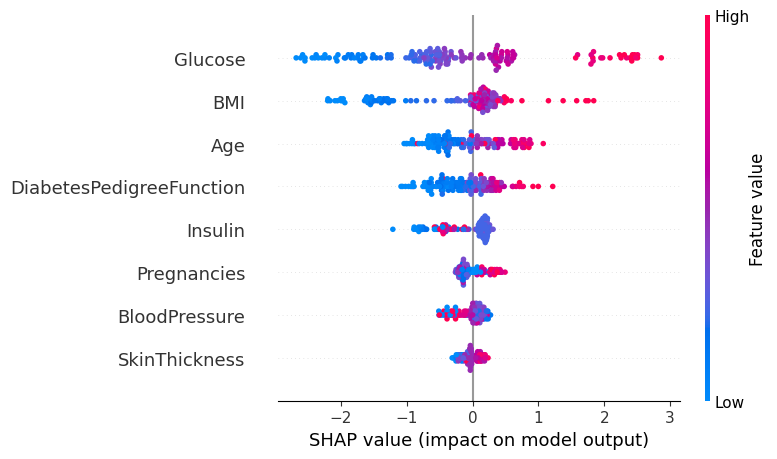

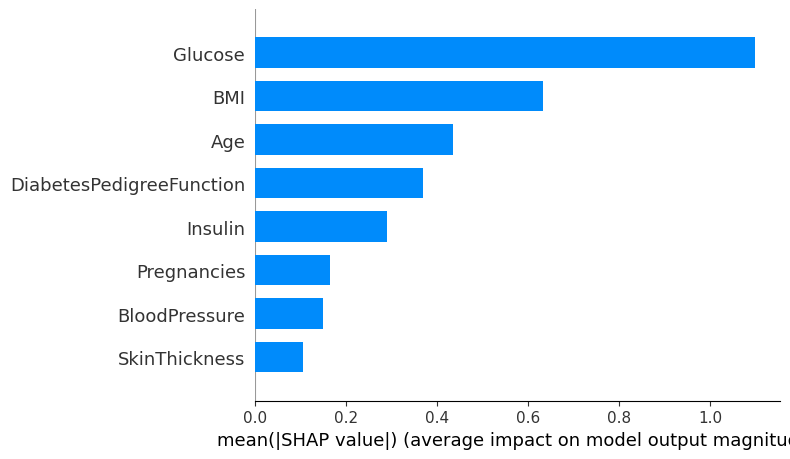

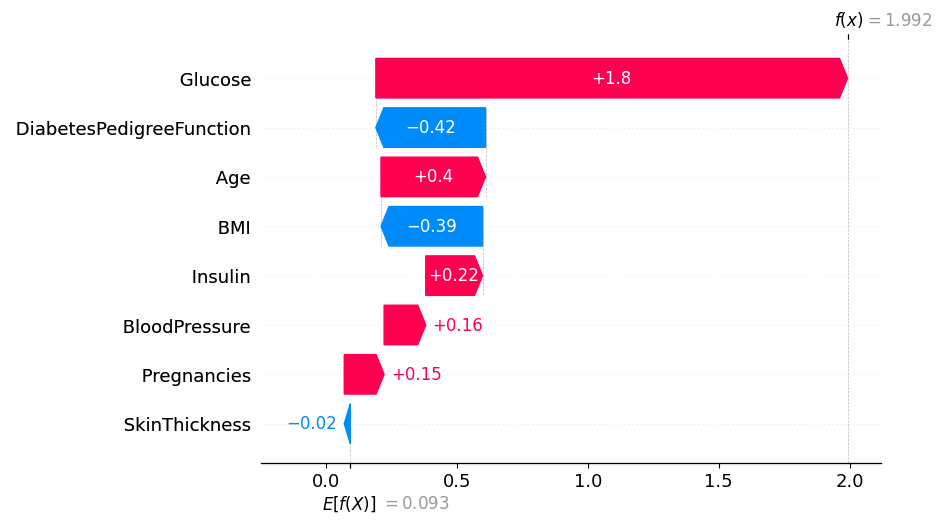